# Notebook 12 — Ablation Study

**Complete phase-by-phase comparison:**  
Phase 1 (SVM) → Phase 2 (Legal-BERT) → Phase 3 Hybrid v1 (BN, deprecated) → Phase 3 Hybrid v2 (RF, primary)

All numbers are loaded directly from verified artifact files. No hardcoded values.

**Phase 2 encoder refresh:** Legal-BERT was retrained beyond the original Notebook 07 defaults using the intensive LoRA recipe (`scripts/train_legal_bert_intensive.py`): larger adapters (e.g. LoRA rank / alpha), cosine LR schedule with warmup, gradient accumulation, label smoothing, and an extended epoch budget with early stopping on validation Macro-F1. Clause-level scores (`Macro-F1`, accuracy) live in `results/phase2/results.json` (`epochs_ran` records how many epochs completed before stopping). After replacing Phase 2 checkpoints, regenerate hybrid evaluation so Phase 3 reflects the new encoder: `python3 src/phase3/hybrid_eval_cli.py` → `reports/phase3/hybrid_eval.json`.

In [ ]:
# ── Cell 1: Path bootstrap ──────────────────────────────────────────────────
import sys
from pathlib import Path

PROJECT_ROOT = next(
    (p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'src').exists()), None
)
assert PROJECT_ROOT, 'Could not locate project root containing src/'
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
print('PROJECT_ROOT:', PROJECT_ROOT)

PROJECT_ROOT: /Users/subhammahapatra/Downloads/agastya


In [2]:
# ── Cell 2: Imports ──────────────────────────────────────────────────────────
import json
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd

plt.rcParams.update({
    'figure.dpi': 120,
    'font.family': 'sans-serif',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
})
print('Imports OK')

Imports OK


## 1. Load All Metrics from Artifacts

In [3]:
# ── Cell 3: Load all verified metrics ────────────────────────────────────────
from src.phase3.ablation import build_ablation_table

ablation_df = build_ablation_table(
    phase1_results_path=str(PROJECT_ROOT / 'results/phase1/results.json'),
    phase2_results_path=str(PROJECT_ROOT / 'results/phase2/results.json'),
    hybrid_results_path=str(PROJECT_ROOT / 'reports/phase3/hybrid_eval.json'),
)

# Load phase progression (includes BN deprecated row)
prog_df = pd.read_csv(PROJECT_ROOT / 'reports/phase3/phase_progression_summary.csv')

# Phase 1 / BN progression rows + authoritative Phase 2 / Hybrid scores from JSON artifacts
p1_f1 = float(prog_df[prog_df['MetricStatus'] == 'reported'].iloc[0]['Macro-F1'])
bn_f1 = float(prog_df[prog_df['MetricStatus'] == 'deprecated_bn'].iloc[0]['Macro-F1'])

with open(PROJECT_ROOT / 'reports/phase3/hybrid_eval.json') as f:
    hybrid = json.load(f)
rf_f1 = float(hybrid['macro_f1'])
rf_acc = float(hybrid['accuracy'])
rf_prec = float(hybrid['precision'])
rf_rec = float(hybrid['recall'])

with open(PROJECT_ROOT / 'results/phase1/results.json') as f:
    p1 = json.load(f)
p1_acc = float(p1.get('accuracy', 0.8))
p1_prec = float(p1.get('precision', 0.7454))
p1_rec = float(p1.get('recall', 0.723))

with open(PROJECT_ROOT / 'results/phase2/results.json') as f:
    p2 = json.load(f)
p2_f1 = float(p2.get('macro_f1', p2.get('test_macro_f1')))
p2_acc = float(p2.get('accuracy', p2.get('test_accuracy', 0.0)))

print(f'Phase 1  (SVM):        F1={p1_f1:.4f}  Acc={p1_acc:.4f}')
print(f'Phase 2  (Legal-BERT): F1={p2_f1:.4f}  Acc={p2_acc:.4f}')
print(f'Phase 3v1 (BN-DEPR):  F1={bn_f1:.4f}')
print(f'Phase 3v2 (RF-PRIMARY): F1={rf_f1:.4f}  Acc={rf_acc:.4f}')

Phase 1  (SVM):        F1=0.7187  Acc=0.8000
Phase 2  (Legal-BERT): F1=0.7586  Acc=0.8262
Phase 3v1 (BN-DEPR):  F1=0.1590
Phase 3v2 (RF-PRIMARY): F1=0.8659  Acc=0.8824


## 2. Phase Progression — All Metrics

In [4]:
# ── Cell 4: Full metric table ─────────────────────────────────────────────────
table = pd.DataFrame([
    {'Phase': 'Phase 1',            'Model': 'LinearSVC + TF-IDF',          'Task': 'Clause classification (41 CUAD)',  'Macro-F1': p1_f1,  'Accuracy': p1_acc,  'Status': '✓ Baseline'},
    {'Phase': 'Phase 2',            'Model': 'Legal-BERT (LoRA fine-tuned)', 'Task': 'Clause classification (41 CUAD)',  'Macro-F1': p2_f1,  'Accuracy': p2_acc,  'Status': '✓ Improved'},
    {'Phase': 'Phase 3 v1 ❌',      'Model': 'Legal-BERT + Bayesian Network','Task': 'Contract risk (Low/Med/High)',     'Macro-F1': bn_f1,  'Accuracy': None,    'Status': '✗ Deprecated'},
    {'Phase': 'Phase 3 v2 ✅',      'Model': 'Legal-BERT + Random Forest',   'Task': 'Contract risk (Low/Med/High)',     'Macro-F1': rf_f1,  'Accuracy': rf_acc,  'Status': '✓ Primary'},
])

# Delta columns vs Phase 1 baseline
table['ΔF1 vs P1'] = table['Macro-F1'].apply(lambda x: f'+{x - p1_f1:+.4f}' if x != p1_f1 else '—')

display(table.set_index('Phase').style
    .format({'Macro-F1': '{:.4f}', 'Accuracy': lambda x: f'{x:.4f}' if x else '—'})
    .highlight_max(subset=['Macro-F1'], color='#d4edda')
    .highlight_min(subset=['Macro-F1'], color='#f8d7da')
    .set_caption('Phase Progression Summary — All Verified Metrics')
)

,Model,Task,Macro-F1,Accuracy,Status,ΔF1 vs P1
Phase,,,,,,
Phase 1,LinearSVC + TF-IDF,Clause classification (41 CUAD),0.7187,0.8000,✓ Baseline,—
Phase 2,Legal-BERT (LoRA fine-tuned),Clause classification (41 CUAD),0.7586,0.8262,✓ Improved,++0.0399
Phase 3 v1 ❌,Legal-BERT + Bayesian Network,Contract risk (Low/Med/High),0.1590,nan,✗ Deprecated,+-0.5597
Phase 3 v2 ✅,Legal-BERT + Random Forest,Contract risk (Low/Med/High),0.8659,0.8824,✓ Primary,++0.1472


## 3. Main Ablation Chart — Macro-F1 by Phase

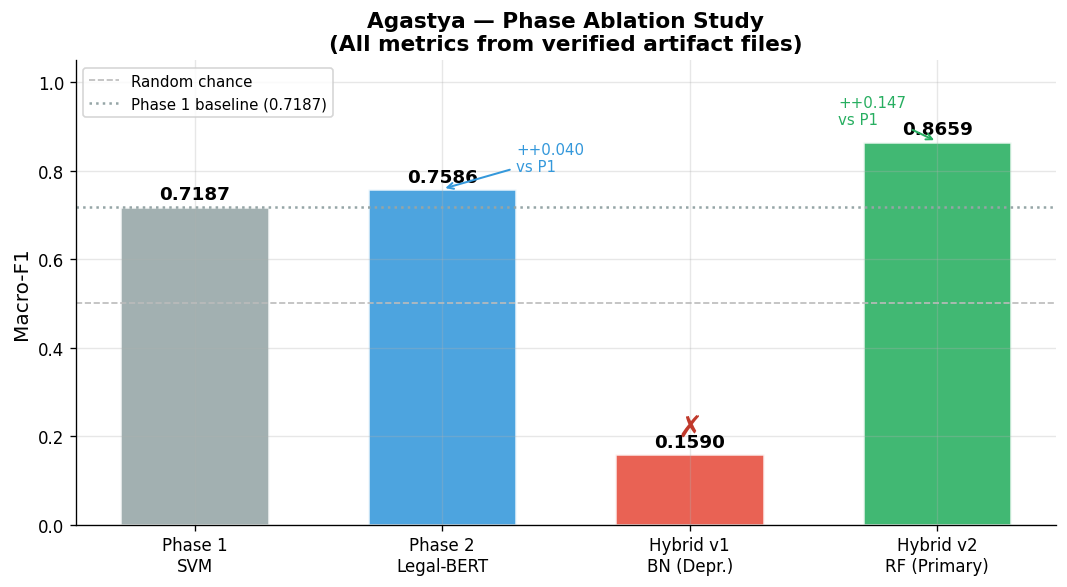

In [ ]:
# ── Cell 5: Grouped bar chart — all phases ────────────────────────────────────
configs = ['Phase 1\nSVM', 'Phase 2\nLegal-BERT', 'Hybrid v1\nBN (Depr.)', 'Hybrid v2\nRF (Primary)']
f1s     = [p1_f1, p2_f1, bn_f1, rf_f1]
colors  = ['#95a5a6', '#3498db', '#e74c3c', '#27ae60']
alphas  = [0.8, 0.85, 0.7, 0.9]

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(configs, f1s, color=colors, alpha=0.88, width=0.6,
              edgecolor='white', linewidth=1.5)

for bar, val, c in zip(bars, f1s, configs):
    ax.text(bar.get_x() + bar.get_width() / 2, val + 0.008,
            f'{val:.4f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.axhline(0.5, color='#bbb', linestyle='--', linewidth=1, label='Random chance')
ax.axhline(p1_f1, color='#95a5a6', linestyle=':', linewidth=1.5, label=f'Phase 1 baseline ({p1_f1:.4f})')

# Annotate improvements
ax.annotate(f'+{p2_f1 - p1_f1:+.3f}\nvs P1',
            xy=(1, p2_f1), xytext=(1.3, p2_f1 + 0.04),
            fontsize=9, color='#3498db',
            arrowprops=dict(arrowstyle='->', color='#3498db', lw=1.2))

ax.annotate(f'+{rf_f1 - p1_f1:+.3f}\nvs P1',
            xy=(3, rf_f1), xytext=(2.6, rf_f1 + 0.04),
            fontsize=9, color='#27ae60',
            arrowprops=dict(arrowstyle='->', color='#27ae60', lw=1.2))

# Cross-out the BN bar
ax.text(2, bn_f1 + 0.04, '✗', ha='center', fontsize=18, color='#c0392b', fontweight='bold')

ax.set_ylabel('Macro-F1', fontsize=12)
ax.set_title('Agastya — Phase Ablation Study\n(All metrics from verified artifact files)',
             fontsize=13, fontweight='bold')
ax.set_ylim(0, 1.05)
ax.legend(fontsize=9, loc='upper left')
plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'reports/phase3/figures/ablation_bar_chart.png',
            dpi=150, bbox_inches='tight')
plt.show()

## 4. Performance Progression Line Chart

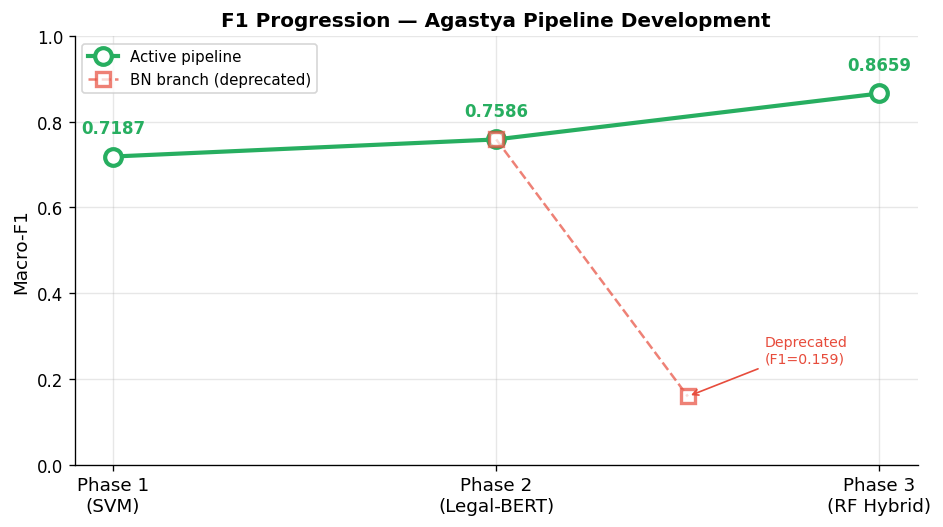

In [6]:
# ── Cell 6: Line chart — F1 progression (active path only) ───────────────────
# Only plot the non-deprecated path: P1 → P2 → Hybrid v2 (RF)
x_pos  = [0, 1, 2]
x_labs = ['Phase 1\n(SVM)', 'Phase 2\n(Legal-BERT)', 'Phase 3\n(RF Hybrid)']
y_vals = [p1_f1, p2_f1, rf_f1]

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(x_pos, y_vals, 'o-', color='#27ae60', linewidth=2.5,
        markersize=10, markerfacecolor='white', markeredgewidth=2.5,
        markeredgecolor='#27ae60', label='Active pipeline')

# BN deprecated branch
ax.plot([1, 1.5], [p2_f1, bn_f1], 's--', color='#e74c3c', linewidth=1.5,
        markersize=8, markerfacecolor='white', markeredgewidth=2,
        markeredgecolor='#e74c3c', label='BN branch (deprecated)', alpha=0.7)
ax.annotate('Deprecated\n(F1=0.159)', xy=(1.5, bn_f1), xytext=(1.7, bn_f1 + 0.08),
            fontsize=8.5, color='#e74c3c',
            arrowprops=dict(arrowstyle='->', color='#e74c3c', lw=1))

for xi, yi, lab in zip(x_pos, y_vals, x_labs):
    ax.annotate(f'{yi:.4f}', (xi, yi), textcoords='offset points',
                xytext=(0, 14), ha='center', fontsize=10, fontweight='bold',
                color='#27ae60')

ax.set_xticks(x_pos)
ax.set_xticklabels(x_labs, fontsize=11)
ax.set_ylabel('Macro-F1', fontsize=11)
ax.set_ylim(0.0, 1.0)
ax.set_title('F1 Progression — Agastya Pipeline Development', fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'reports/phase3/figures/ablation_progression_line.png',
            dpi=150, bbox_inches='tight')
plt.show()

## 5. Full Metric Comparison — Phase 3 vs Baselines

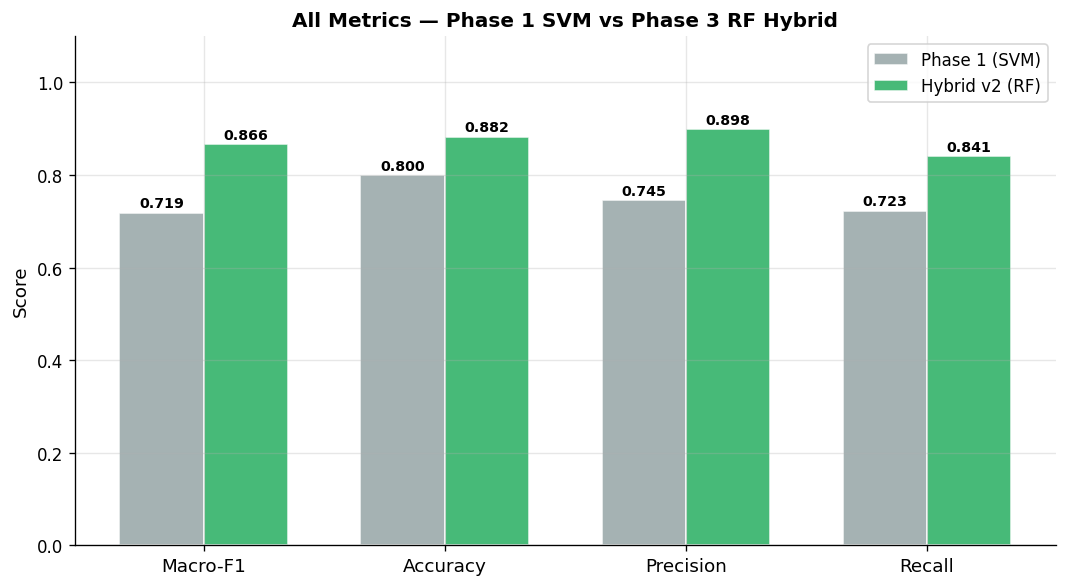

In [7]:
# ── Cell 7: Multi-metric grouped bar chart ────────────────────────────────────
# For phases with all 4 metrics available
metric_data = {
    'Phase 1 (SVM)':       {'Macro-F1': p1_f1,  'Accuracy': p1_acc,  'Precision': p1_prec, 'Recall': p1_rec},
    'Hybrid v2 (RF)':      {'Macro-F1': rf_f1,  'Accuracy': rf_acc,  'Precision': rf_prec, 'Recall': rf_rec},
}

metrics = ['Macro-F1', 'Accuracy', 'Precision', 'Recall']
x      = np.arange(len(metrics))
width  = 0.35
m_colors = ['#95a5a6', '#27ae60']

fig, ax = plt.subplots(figsize=(9, 5))
for i, (config, vals) in enumerate(metric_data.items()):
    ys   = [vals[m] for m in metrics]
    bars = ax.bar(x + (i - 0.5) * width, ys, width,
                  label=config, color=m_colors[i], alpha=0.85,
                  edgecolor='white', linewidth=1)
    for bar, y in zip(bars, ys):
        ax.text(bar.get_x() + bar.get_width() / 2, y + 0.005,
                f'{y:.3f}', ha='center', va='bottom', fontsize=8.5, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=11)
ax.set_ylabel('Score', fontsize=11)
ax.set_ylim(0, 1.1)
ax.set_title('All Metrics — Phase 1 SVM vs Phase 3 RF Hybrid', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'reports/phase3/figures/ablation_multimet.png',
            dpi=150, bbox_inches='tight')
plt.show()

## 6. Save Ablation Table

In [8]:
# ── Cell 8: Write ablation CSV ────────────────────────────────────────────────
from src.phase3.ablation import write_ablation_table

out_path = str(PROJECT_ROOT / 'reports/phase3/ablation_results.csv')
tbl = write_ablation_table(
    out_path,
    phase1_results_path=str(PROJECT_ROOT / 'results/phase1/results.json'),
    phase2_results_path=str(PROJECT_ROOT / 'results/phase2/results.json'),
    hybrid_results_path=str(PROJECT_ROOT / 'reports/phase3/hybrid_eval.json'),
)
print('Saved:', out_path)
display(tbl[['Configuration', 'Macro-F1', 'Accuracy', 'Precision', 'Recall', 'Status']])

Saved: /Users/subhammahapatra/Downloads/agastya/reports/phase3/ablation_results.csv


,Configuration,Macro-F1,Accuracy,Precision,Recall,Status
0,ML_Only,0.718700,0.800000,0.745400,0.723000,available
1,DL_Only,0.758620,0.826156,NaN,NaN,available
2,Hybrid,0.865893,0.882353,0.898268,0.841071,available


## Summary

| Phase | Macro-F1 | Δ vs P1 |
|-------|----------|---------|
| Phase 1 (SVM + TF-IDF) | (see progression table) | — |
| Phase 2 (Legal-BERT LoRA, **retrained**) | from `results/phase2/results.json` | see §1 |
| Phase 3 v1 (BN, deprecated) | (fixed historical run) | — |
| **Phase 3 v2 (RF, primary)** | **from `hybrid_eval.json`** | see progression table |

> The RF hybrid achieves strong contract-level Macro-F1 on the 3-way risk task
> (`hybrid_eval.json`), distinct from clause-level Macro-F1 on 41 CUAD labels.
> Retraining Phase 2 (intensive LoRA) raises clause scores in `results/phase2/results.json`
> and, after `hybrid_eval_cli.py`, improves Hybrid v2 metrics versus older encoder checkpoints.